In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Add project root to Python path
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import CLIP_METADATA_PATH
from src.video_utils import (
    load_clip_metadata,
    validate_video_paths,
    get_video_frame_count,
    load_sampled_frames,
)

In [2]:
df = load_clip_metadata(CLIP_METADATA_PATH)
df.head()

,clip_id,video_path,label
0,bad_jump_01,data/raw/bad/bad_jump_01.MOV,bad_jump
1,bad_jump_02,data/raw/bad/bad_jump_02.MOV,bad_jump
2,bad_jump_03,data/raw/bad/bad_jump_03.MOV,bad_jump
3,bad_jump_04,data/raw/bad/bad_jump_04.MOV,bad_jump
4,bad_jump_05,data/raw/bad/bad_jump_05.MOV,bad_jump


In [3]:
print("Number of clips:", len(df))
print("\nClass counts:")
print(df["label"].value_counts())

Number of clips: 30

Class counts:
label
bad_jump     15
good_jump    15
Name: count, dtype: int64


In [4]:
df_checked = validate_video_paths(df)
df_checked[["clip_id", "video_path", "file_exists"]].head()

,clip_id,video_path,file_exists
0,bad_jump_01,data/raw/bad/bad_jump_01.MOV,True
1,bad_jump_02,data/raw/bad/bad_jump_02.MOV,True
2,bad_jump_03,data/raw/bad/bad_jump_03.MOV,True
3,bad_jump_04,data/raw/bad/bad_jump_04.MOV,True
4,bad_jump_05,data/raw/bad/bad_jump_05.MOV,True


In [5]:
print("All files exist:", df_checked["file_exists"].all())

missing_files = df_checked.loc[
    ~df_checked["file_exists"],
    ["clip_id", "video_path", "absolute_path"]
]

missing_files

All files exist: True


,clip_id,video_path,absolute_path


In [6]:
sample_row = df_checked.iloc[0]
sample_row

clip_id                                                bad_jump_01
video_path                            data/raw/bad/bad_jump_01.MOV
label                                                     bad_jump
absolute_path    /Users/arjunrammohandas/Desktop/JumpSafe_Conti...
file_exists                                                   True
Name: 0, dtype: object

In [7]:
video_path = sample_row["absolute_path"]
label = sample_row["label"]
clip_id = sample_row["clip_id"]

print("Clip ID:", clip_id)
print("Label:", label)
print("Absolute path:", video_path)

Clip ID: bad_jump_01
Label: bad_jump
Absolute path: /Users/arjunrammohandas/Desktop/JumpSafe_Continuation/data/raw/bad/bad_jump_01.MOV


In [8]:
frame_count = get_video_frame_count(video_path)
print("Frame count:", frame_count)

Frame count: 169


In [9]:
frames, frame_indices = load_sampled_frames(video_path, num_samples=6)

print("Loaded frames:", len(frames))
print("Frame indices:", frame_indices)
print("Frame shape:", frames[0].shape)

Loaded frames: 6
Frame indices: [  0  33  67 100 134 168]
Frame shape: (1080, 1920, 3)


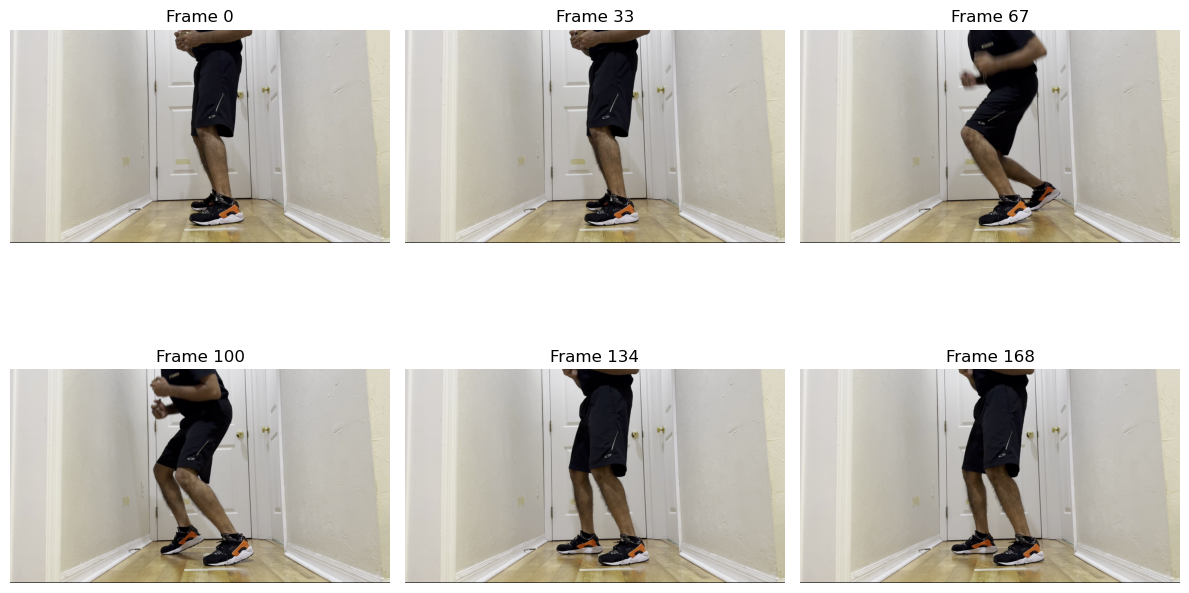

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, frame, idx in zip(axes, frames, frame_indices):
    ax.imshow(frame)
    ax.set_title(f"Frame {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()